# Лабораторная работа 3. Регрессия полносвязной сетью
## Остаточный ресурс Li-ion батареи (NASA PCoE)

**Цель:** по табличным признакам одного цикла разряда предсказать число — сколько циклов осталось до конца ресурса (RUL). Реализовать Dense-сеть с линейным выходом, обучить её функцией потерь MSE, сравнить с MAE-loss и оценить качество метриками MAE и RMSE.


## 0. Импорты

Сеть пишем сами на NumPy. `pandas` — таблица циклов, `sklearn` — только стандартизация и метрики.


In [1]:
# === Импорты: подключаем нужные библиотеки ===
import warnings  # чтобы единичный overflow не забивал вывод тысячи строк
import numpy as np  # массивы и математика (основа сети)
import pandas as pd  # таблица циклов разряда
import matplotlib.pyplot as plt  # графики деградации, loss и прогнозов
from pathlib import Path  # папка для картинок
from sklearn.preprocessing import StandardScaler  # Z-нормализация признаков и цели
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # MAE, MSE, R^2

np.random.seed(42)  # фиксируем случайность, чтобы результаты повторялись
warnings.filterwarnings("ignore", category=RuntimeWarning)  # inf в matmul не печатаем пачкой
plt.rcParams["figure.figsize"] = (8, 5)  # размер графиков по умолчанию
plt.rcParams["font.size"] = 11  # размер шрифта на графиках
FIG_DIR = Path("figures_lab3")  # куда сохранять рисунки
FIG_DIR.mkdir(exist_ok=True)  # создаём папку, если её ещё нет
print("OK")  # проверка: ячейка выполнилась


OK


## 1. Теория: регрессия, потери, метрики

В классификации (лабы 1–2) сеть выбирала класс. Здесь ответ — **число**: остаточный ресурс в циклах.

Выходной слой — **linear**: \(\hat y = Z\), без активации. Softmax выдал бы вероятности классов, сигмоида сжала бы прогноз в (0, 1). Для произвольного числа циклов нужна тождественная активация.

### MSE — основная функция потерь

\[
L_{\mathrm{MSE}} = \frac{1}{m}\sum_{i=1}^{m}(\hat y_i - y_i)^2,
\qquad
\frac{\partial L_{\mathrm{MSE}}}{\partial \hat y_i} = \frac{2}{m}(\hat y_i - y_i).
\]

Квадрат сильнее наказывает крупные промахи: ошибка в 10 циклов стоит как 100 ошибок в 1 цикл.

### MAE — альтернативная функция потерь

\[
L_{\mathrm{MAE}} = \frac{1}{m}\sum_{i=1}^{m}|\hat y_i - y_i|,
\qquad
\frac{\partial L_{\mathrm{MAE}}}{\partial \hat y_i} = \frac{1}{m}\operatorname{sign}(\hat y_i - y_i).
\]

Каждый цикл ошибки входит линейно, выброс не перетягивает веса так сильно, как в MSE. В нуле производная модуля не определена; в коде берём \(\operatorname{sign}(0) = 0\).

### Метрики (ими оцениваем, ими не обязательно учим)

\[
\mathrm{MAE} = \frac{1}{m}\sum_{i=1}^{m}|\hat y_i - y_i|,
\qquad
\mathrm{RMSE} = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(\hat y_i - y_i)^2}.
\]

Обе метрики в тех же единицах, что и цель (циклы). RMSE всегда не меньше MAE на одном и том же наборе ошибок: квадратичное среднее не меньше среднего модулей.

Сеть учится на **стандартизованных** \(X\) и \(y\) (среднее 0, разброс 1). MAE и RMSE считаем после обратного масштаба — в циклах, иначе цифра ничего не говорит о ресурсе батареи.


## 2. Данные NASA PCoE

**Источник:** B. Saha, K. Goebel (2007). *Battery Data Set*, NASA Prognostics Data Repository, NASA Ames Research Center.  
Страница репозитория: <https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/>  
Архив: <https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip> (комнатные батареи лежат во внутреннем файле `1. BatteryAgingARC-FY08Q4.zip`).

Четыре ячейки 18650, номинал 2 А·ч, температура 24 °C:

| Батарея | Разряд | Зачем в лабе |
|---|---|---|
| B0005 | 2 А до 2.7 В | обучение |
| B0006 | 2 А до 2.5 В | обучение |
| B0018 | 2 А до 2.5 В | тест, сеть её не видит |
| B0007 | 2 А до 2.2 В | только график: другой порог напряжения, ёмкость несопоставима |

Каждый опыт — заряд, разряд и спектр импеданса. Конец ресурса в постановке NASA: ёмкость упала на 30%, с 2.0 до **1.4 А·ч**.

Файл `data/nasa_battery/discharge_cycles.csv` — уже свёрнутые циклы разряда (одна строка = один discharge из `.mat`):

- `capacity` — ёмкость, А·ч (поле `Capacity`);
- `discharge_duration` — длительность разряда, с;
- `v_mean`, `v_min`, `v_std`, `v_end` — статистики `Voltage_measured`;
- `t_mean`, `t_max`, `t_rise` — статистики `Temperature_measured` (`t_rise = t_max - t_start`);
- `i_mean` — средний модуль тока.

**Цель**

\[
\mathrm{RUL}(n) = n_{\mathrm{EOL}} - n,
\]

где \(n_{\mathrm{EOL}}\) — первый цикл с `capacity ≤ 1.4`. В признаки номер цикла и сам RUL не кладём: на новой батарее номер цикла ничего не знает о её скорости старения, а RUL — это и есть ответ.

Циклы **после** EOL отбрасываем: ресурс уже исчерпан, метка была бы нулём. B0007 в обучение не берём.


In [2]:
# === Загрузка сводки циклов разряда ===
DATA_PATH = Path("data/nasa_battery/discharge_cycles.csv")  # таблица, собранная из NASA .mat
if not DATA_PATH.exists():
    DATA_PATH = Path("lab01_regression") / DATA_PATH  # если ноутбук открыт из корня репозитория
df = pd.read_csv(DATA_PATH)  # читаем все циклы четырёх батарей
df = df.sort_values(["cell_id", "cycle_index"]).reset_index(drop=True)  # порядок: батарея, затем цикл

print("Файл:", DATA_PATH)  # откуда взяли данные
print("Строк (циклов разряда):", len(df))  # сколько циклов всего
print("Батареи:", sorted(df["cell_id"].unique()))  # имена ячеек
print("Столбцы:", list(df.columns))  # какие поля есть в таблице
print()  # пустая строка
print(df.groupby("cell_id")["capacity"].agg(["count", "first", "min", "last"]).round(3))  # ёмкость: старт, минимум, конец


Файл: data/nasa_battery/discharge_cycles.csv
Строк (циклов разряда): 636
Батареи: ['B0005', 'B0006', 'B0007', 'B0018']
Столбцы: ['cell_id', 'cycle_index', 'ambient_temperature', 'capacity', 'v_start', 'v_end', 'v_min', 'v_mean', 'v_std', 'i_mean', 't_start', 't_max', 't_mean', 't_rise', 'discharge_duration', 'energy_discharged']

         count  first    min   last
cell_id                            
B0005      168  1.856  1.287  1.325
B0006      168  2.035  1.154  1.186
B0007      168  1.891  1.400  1.432
B0018      132  1.855  1.341  1.341


In [3]:
# === Метка RUL: циклы до падения ёмкости до 1.4 А·ч ===
EOL_AH = 1.4  # порог конца ресурса из постановки NASA (30% от номинала 2 А·ч)

parts = []  # сюда сложим батареи уже с колонкой rul
for cell_id, group in df.groupby("cell_id"):  # обрабатываем каждую ячейку отдельно
    g = group.sort_values("cycle_index").copy()  # циклы по возрастанию номера
    hit = g.loc[g["capacity"] <= EOL_AH, "cycle_index"]  # номера циклов, где ёмкость уже ≤ 1.4
    if len(hit) > 0:  # батарея дожила до критерия EOL
        eol_cycle = int(hit.iloc[0])  # первый такой цикл
        g["reached_eol"] = 1  # метку RUL можно ставить честно
    else:  # эксперимент остановили раньше порога (цензура)
        eol_cycle = int(g["cycle_index"].max())  # последний наблюдаемый цикл — не настоящий EOL
        g["reached_eol"] = 0  # такую ячейку не учим
    g["eol_cycle"] = eol_cycle  # запоминаем номер EOL
    g["rul"] = eol_cycle - g["cycle_index"]  # сколько циклов осталось, считая текущий как 0 в момент EOL
    parts.append(g)  # сохраняем батарею

cycles = pd.concat(parts, ignore_index=True)  # снова одна таблица

# В обучение идут только ячейки, дошедшие до 1.4 А·ч, и только циклы до EOL включительно
labeled = cycles[(cycles["reached_eol"] == 1) & (cycles["cycle_index"] <= cycles["eol_cycle"])].copy()

print("EOL, А·ч:", EOL_AH)  # порог
for cell_id, g in cycles.groupby("cell_id"):  # краткий отчёт по каждой батарее
    flag = "дошла до 1.4" if g["reached_eol"].iloc[0] == 1 else "НЕ дошла до 1.4 (в модель не берём)"
    print(f"  {cell_id}: циклов в файле {len(g):3d}, eol_cycle={int(g['eol_cycle'].iloc[0]):3d}, {flag}")

print("Строк с честным RUL (до EOL):", len(labeled))  # размер задачи регрессии
print(labeled.groupby("cell_id")["rul"].agg(["count", "max"]).rename(columns={"max": "rul_at_start"}))  # ресурс в начале


EOL, А·ч: 1.4
  B0005: циклов в файле 168, eol_cycle=125, дошла до 1.4
  B0006: циклов в файле 168, eol_cycle=109, дошла до 1.4
  B0007: циклов в файле 168, eol_cycle=168, НЕ дошла до 1.4 (в модель не берём)
  B0018: циклов в файле 132, eol_cycle= 97, дошла до 1.4
Строк с честным RUL (до EOL): 331
         count  rul_at_start
cell_id                     
B0005      125           124
B0006      109           108
B0018       97            96


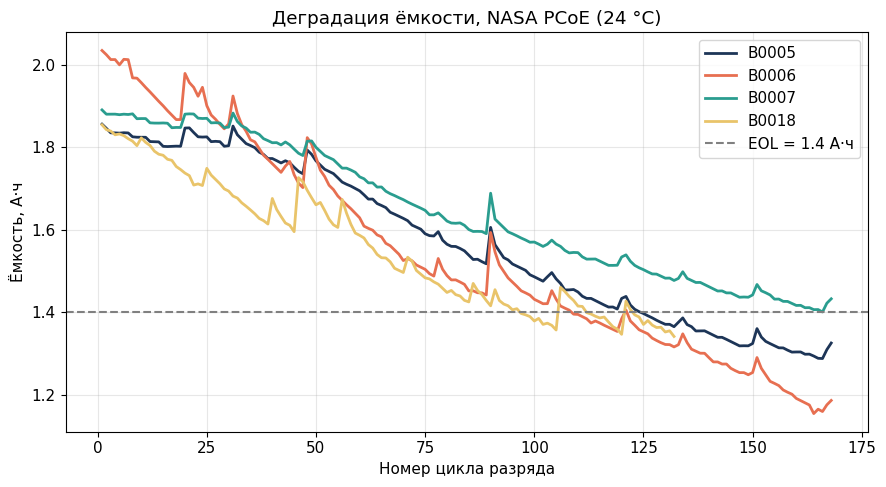

Вывод:
· Ёмкость падает не идеально гладко: бывают скачки вверх (регенерация после отдыха).
· B0005, B0006 и B0018 пересекают 1.4 А·ч. B0007 разряжали глубже (до 2.2 В), её ёмкость с ними не сравниваем.


In [4]:
# === График: как падает ёмкость и где порог 1.4 А·ч ===
colors = {"B0005": "#1d3557", "B0006": "#e76f51", "B0007": "#2a9d8f", "B0018": "#e9c46a"}  # цвет каждой батареи

plt.figure(figsize=(9, 5))  # холст
for cell_id, g in cycles.groupby("cell_id"):  # отдельная кривая на ячейку
    plt.plot(g["cycle_index"], g["capacity"], label=cell_id, color=colors[cell_id], lw=2)  # ёмкость от номера цикла
plt.axhline(EOL_AH, color="gray", ls="--", label=f"EOL = {EOL_AH} А·ч")  # горизонталь порога
plt.xlabel("Номер цикла разряда")  # ось X
plt.ylabel("Ёмкость, А·ч")  # ось Y
plt.title("Деградация ёмкости, NASA PCoE (24 °C)")  # заголовок
plt.legend()  # легенда
plt.grid(True, alpha=0.3)  # сетка
plt.tight_layout()  # компоновка
plt.savefig(FIG_DIR / "capacity_fade.png", dpi=120, bbox_inches="tight")  # сохранить
plt.show()  # показать

print("Вывод:")  # короткая интерпретация графика
print("· Ёмкость падает не идеально гладко: бывают скачки вверх (регенерация после отдыха).")
print("· B0005, B0006 и B0018 пересекают 1.4 А·ч. B0007 разряжали глубже (до 2.2 В), её ёмкость с ними не сравниваем.")


## 3. Признаки, разбиение, стандартизация

Признаки — только то, что известно **в конце текущего разряда**. Номер цикла и RUL в \(X\) не входят.

Утечка, которую здесь легко допустить: случайно разрезать циклы одной батареи на train и test. Соседние циклы почти копии друг друга, тест перестаёт быть проверкой. Поэтому учим на **B0005 и B0006**, а считаем метрики на **B0018**.


In [5]:
# === Какие столбцы подаём на вход сети ===
FEATURE_COLS = [  # признаки одного цикла разряда
    "capacity",  # измеренная ёмкость, А·ч — прямой индикатор здоровья
    "discharge_duration",  # сколько секунд длился разряд (при токе ~2 А почти пропорциональна ёмкости)
    "v_mean",  # среднее напряжение за разряд
    "v_min",  # минимум напряжения
    "v_std",  # разброс напряжения по циклу
    "v_end",  # напряжение в конце записи
    "t_mean",  # средняя температура
    "t_max",  # максимальная температура
    "t_rise",  # насколько нагрелась ячейка за разряд
]

TRAIN_IDS = ["B0005", "B0006"]  # на этих батареях учим веса
TEST_ID = "B0018"  # эту батарею сеть не видит до оценки

train_df = labeled[labeled["cell_id"].isin(TRAIN_IDS)].copy()  # обучающие циклы
test_df = labeled[labeled["cell_id"] == TEST_ID].copy()  # тестовые циклы

print("Train:", TRAIN_IDS, train_df.shape[0], "циклов")  # размер обучения
print("Test:", TEST_ID, test_df.shape[0], "циклов")  # размер теста
print("Признаков:", len(FEATURE_COLS))  # ширина входа
print()  # пустая строка
print("Фрагмент обучающей таблицы:")  # как выглядит одна строка
print(train_df[["cell_id", "cycle_index", "rul"] + FEATURE_COLS].head(3).round(3).to_string(index=False))


Train: ['B0005', 'B0006'] 234 циклов
Test: B0018 97 циклов
Признаков: 9

Фрагмент обучающей таблицы:
cell_id  cycle_index  rul  capacity  discharge_duration  v_mean  v_min  v_std  v_end  t_mean  t_max  t_rise
  B0005            1  124     1.856            3690.234   3.530  2.612  0.236  3.277  32.572 38.982  14.652
  B0005            2  123     1.846            3672.344   3.537  2.587  0.235  3.300  32.725 39.033  14.336
  B0005            3  122     1.835            3651.641   3.544  2.652  0.228  3.327  32.643 38.819  14.085


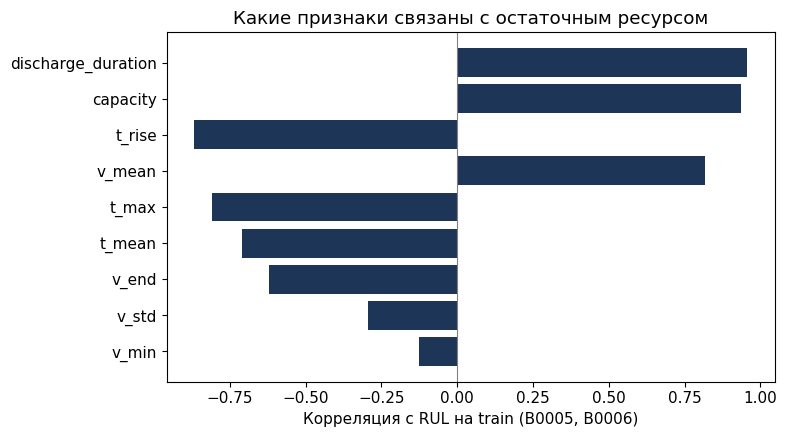

discharge_duration    0.956
capacity              0.935
t_rise               -0.868
v_mean                0.817
t_max                -0.810
t_mean               -0.712
v_end                -0.621
v_std                -0.296
v_min                -0.126

Вывод:
· Ёмкость и длительность разряда почти повторяют старение: ток разряда около 2 А, поэтому А·ч ≈ ток × время.
· Напряжение и температура тоже связаны с RUL, но слабее. Ниже сравним модель с ёмкостью и без неё.


In [6]:
# === Насколько каждый признак линейно связан с RUL (только train) ===
corr = train_df[FEATURE_COLS + ["rul"]].corr(numeric_only=True)["rul"].drop("rul")  # корреляция Пирсона с целью
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)  # сначала самые сильные по модулю

plt.figure(figsize=(8, 4.5))  # холст
plt.barh(corr.index[::-1], corr.values[::-1], color="#1d3557")  # горизонтальные столбцы
plt.axvline(0, color="gray", lw=0.8)  # ноль
plt.xlabel("Корреляция с RUL на train (B0005, B0006)")  # подпись оси
plt.title("Какие признаки связаны с остаточным ресурсом")  # заголовок
plt.tight_layout()  # компоновка
plt.savefig(FIG_DIR / "feature_corr.png", dpi=120, bbox_inches="tight")  # сохранить
plt.show()  # показать

print(corr.round(3).to_string())  # те же числа текстом
print()  # пустая строка
print("Вывод:")  # интерпретация
print("· Ёмкость и длительность разряда почти повторяют старение: ток разряда около 2 А, поэтому А·ч ≈ ток × время.")
print("· Напряжение и температура тоже связаны с RUL, но слабее. Ниже сравним модель с ёмкостью и без неё.")


In [7]:
# === Матрицы X, y и Z-нормализация только по train ===

def make_xy(frame, columns):
    '''Таблица циклов → матрица признаков и столбец RUL.'''
    X = frame[columns].to_numpy(dtype=float)  # (N, d)
    y = frame["rul"].to_numpy(dtype=float).reshape(-1, 1)  # (N, 1), чтобы слой имел один выход
    return X, y  # оба массива float


X_train_raw, y_train = make_xy(train_df, FEATURE_COLS)  # сырые признаки и цель, train
X_test_raw, y_test = make_xy(test_df, FEATURE_COLS)  # то же для теста

x_scaler = StandardScaler()  # среднее и std по каждому признаку
X_train = x_scaler.fit_transform(X_train_raw)  # учим масштаб на train и сразу преобразуем train
X_test = x_scaler.transform(X_test_raw)  # тест теми же μ и σ, без подглядывания

y_scaler = StandardScaler()  # отдельный масштаб для цели (циклы имеют разброс в десятки)
y_train_s = y_scaler.fit_transform(y_train)  # цель в стандартизованных единицах — на ней считаем loss
y_test_s = y_scaler.transform(y_test)  # тест тем же масштабом (для кривой loss; метрики будут в циклах)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)  # формы входа
print("y_train, циклы: min", float(y_train.min()), "max", float(y_train.max()))  # диапазон RUL
print("Средние X_train ≈ 0:", X_train.mean(axis=0).round(4))  # проверка нормализации
print("Стд. X_train ≈ 1:", X_train.std(axis=0).round(4))  # проверка нормализации


X_train: (234, 9) | X_test: (97, 9)
y_train, циклы: min 0.0 max 124.0
Средние X_train ≈ 0: [ 0.  0. -0.  0.  0. -0. -0.  0.  0.]
Стд. X_train ≈ 1: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Полносвязная сеть для регрессии

Один слой: \(Z = A_{\mathrm{prev}} W + b\), затем ReLU на скрытых слоях и linear на выходе.

Обратный проход начинается с \(\partial L / \partial \hat y\). Для ReLU производная — 1 на положительном \(Z\) и 0 на отрицательном. Для linear производная равна 1, градиент проходит дальше как есть.

Базовая архитектура: \(d \rightarrow 16 \rightarrow 1\) (один скрытый слой). Второй скрытый слой на двух батареях легко подгоняет шум — это проверяем отдельно.


In [8]:
# === Функции потерь: значение и градиент по прогнозу ===

def mse_loss_and_grad(y_true, y_pred):
    '''MSE и dL/d y_pred. L = mean((y_pred - y_true)^2).'''
    err = y_pred - y_true  # ошибка по каждому объекту батча
    loss = np.mean(err ** 2)  # средний квадрат
    grad = (2.0 / y_true.shape[0]) * err  # производная среднего квадрата
    return loss, grad  # скаляр и матрица той же формы, что y_pred


def mae_loss_and_grad(y_true, y_pred):
    '''MAE и субградиент. L = mean(|y_pred - y_true|).'''
    err = y_pred - y_true  # ошибка
    loss = np.mean(np.abs(err))  # средний модуль
    grad = np.sign(err) / y_true.shape[0]  # sign(0)=0; делим на m, потому что loss — среднее
    return loss, grad  # скаляр и градиент


In [9]:
# === Класс DenseLayer: один полносвязный слой ===

class DenseLayer:
    '''Z = A_prev @ W + b, затем ReLU или linear.

    Формы:
    - A_prev: (batch, n_in)
    - W: (n_in, n_out)
    - b: (1, n_out)
    - A: (batch, n_out)
    '''

    def __init__(self, n_in, n_out, activation="relu", seed=None):
        rng = np.random.default_rng(seed)  # свой генератор случайных чисел
        self.activation_name = activation  # relu на скрытых слоях, linear на выходе
        if activation == "relu":
            std = np.sqrt(2.0 / n_in)  # He-инициализация, чтобы ReLU не «умер» в начале
        elif activation == "linear":
            std = 0.01  # маленький выход: стартовый прогноз около 0 (среднее стандартизованного y)
        else:
            raise ValueError(f"Unknown activation: {activation}")  # опечатка в имени активации
        self.W = rng.normal(0.0, std, size=(n_in, n_out))  # случайные веса
        self.b = np.zeros((1, n_out))  # смещения с нуля
        self.v_W = np.zeros_like(self.W)  # скорость Momentum по W
        self.v_b = np.zeros_like(self.b)  # скорость Momentum по b
        self.A_prev = None  # вход слоя, нужен в backward
        self.Z = None  # линейная часть до активации
        self.A = None  # выход после активации
        self.dW = None  # последний градиент по W
        self.db = None  # последний градиент по b

    def forward(self, A_prev):
        '''Прямой проход одного слоя.'''
        self.A_prev = A_prev  # запоминаем вход
        self.Z = A_prev @ self.W + self.b  # линейное преобразование
        if self.activation_name == "relu":
            self.A = np.maximum(0.0, self.Z)  # ReLU
        else:
            self.A = self.Z  # linear: выход равен Z
        return self.A  # отдаём следующему слою

    def backward(self, dA):
        '''По dL/dA считаем dW, db и dL/dA_prev. Веса здесь ещё не меняем.'''
        if self.activation_name == "relu":
            dZ = dA * (self.Z > 0.0)  # производная ReLU: 0 или 1
        else:
            dZ = dA  # производная linear равна 1
        self.dW = self.A_prev.T @ dZ  # градиент по весам, форма (n_in, n_out)
        self.db = np.sum(dZ, axis=0, keepdims=True)  # градиент по смещениям
        return dZ @ self.W.T  # градиент по входу слоя — его получит предыдущий слой

    def update(self, lr, momentum=0.0, max_norm=5.0):
        '''Шаг SGD. Слишком длинный градиент обрезаем по норме, чтобы веса не стали inf.'''
        grad_norm = np.sqrt(np.sum(self.dW ** 2) + np.sum(self.db ** 2))  # длина градиента слоя
        if not np.isfinite(grad_norm):  # градиент уже не число — шаг пропускаем
            return
        if grad_norm > max_norm:  # обрезка: направление сохраняем, длину ограничиваем
            scale = max_norm / grad_norm
            self.dW = self.dW * scale
            self.db = self.db * scale
        self.v_W = momentum * self.v_W + self.dW  # инерция по весам
        self.v_b = momentum * self.v_b + self.db  # инерция по смещениям
        self.W -= lr * self.v_W  # обновление весов
        self.b -= lr * self.v_b  # обновление смещений


In [10]:
# === Класс NeuralNetwork: несколько Dense-слоёв и выбранная функция потерь ===

class NeuralNetwork:
    '''Регрессионная сеть. loss_name = 'mse' или 'mae'.'''

    def __init__(self, layers, loss_name="mse"):
        self.layers = layers  # список слоёв от входа к выходу
        self.loss_name = loss_name  # какую функцию минимизируем

    def forward(self, X):
        '''Прямой проход. Возвращает прогноз формы (batch, 1) в масштабе обучения.'''
        A = X  # начинаем с признаков
        for layer in self.layers:  # слой за слоем
            A = layer.forward(A)  # выход текущего — вход следующего
        return A  # линейный выход

    def loss_and_grad(self, y_true, y_pred):
        '''Значение loss и dL/d y_pred для выбранной функции.'''
        if self.loss_name == "mse":
            return mse_loss_and_grad(y_true, y_pred)  # квадратичная ошибка
        if self.loss_name == "mae":
            return mae_loss_and_grad(y_true, y_pred)  # модуль ошибки
        raise ValueError(f"Unknown loss: {self.loss_name}")  # опечатка

    def loss(self, X, y_true):
        '''Только значение loss, без обновления весов.'''
        y_pred = self.forward(X)  # прогноз
        value, _ = self.loss_and_grad(y_true, y_pred)  # градиент здесь не нужен
        return value  # скаляр

    def backward_and_update(self, y_true, lr, momentum=0.0):
        '''Обратный проход от уже посчитанного forward и шаг по весам.'''
        y_pred = self.layers[-1].A  # выход последнего слоя после forward
        _, dA = self.loss_and_grad(y_true, y_pred)  # dL/d y_pred
        for layer in reversed(self.layers):  # от выхода к входу
            dA = layer.backward(dA)  # градиент для предыдущего слоя
            layer.update(lr, momentum)  # шаг SGD этого слоя


In [11]:
# === Сборка сети и цикл обучения мини-батчами ===

def build_regressor(n_in, h1=16, h2=None, seed=42, loss_name="mse"):
    '''Сеть n_in → h1 (ReLU) → 1 (linear). Если задан h2, добавляется второй скрытый слой.'''
    layers = [DenseLayer(n_in, h1, activation="relu", seed=seed)]  # первый скрытый слой
    if h2 is None:  # архитектура из одного скрытого слоя
        layers.append(DenseLayer(h1, 1, activation="linear", seed=seed + 1))  # сразу выход
    else:
        layers.append(DenseLayer(h1, h2, activation="relu", seed=seed + 1))  # второй скрытый слой
        layers.append(DenseLayer(h2, 1, activation="linear", seed=seed + 2))  # линейный выход
    return NeuralNetwork(layers, loss_name=loss_name)  # готовая сеть


def predict_cycles(net, X, y_scaler):
    '''Прогноз сети → циклы RUL (обратная стандартизация).'''
    y_scaled = net.forward(X)  # сеть отвечает в масштабе StandardScaler
    return y_scaler.inverse_transform(y_scaled)  # возвращаем циклы


def regression_scores(y_true_cycles, y_pred_cycles):
    '''MAE, RMSE и R^2 в циклах.'''
    y_true = np.asarray(y_true_cycles).ravel()  # вектор истины
    y_pred = np.asarray(y_pred_cycles).ravel()  # вектор прогноза
    mae = mean_absolute_error(y_true, y_pred)  # средняя абсолютная ошибка
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # корень из среднего квадрата
    r2 = r2_score(y_true, y_pred)  # доля объяснённой дисперсии
    return mae, rmse, r2  # три числа


def train_network(
    net, X_tr, y_tr_s, y_tr, X_te, y_te, y_scaler,
    epochs=400, batch_size=32, lr=0.01, momentum=0.0,
    verbose_every=50, seed=42,
):
    '''Мини-батч SGD. В историю пишем MAE/RMSE уже в циклах.'''
    rng = np.random.default_rng(seed)  # генератор для перемешивания батчей
    n = X_tr.shape[0]  # число обучающих циклов
    history = {key: [] for key in ("loss_train", "mae_train", "rmse_train", "mae_test", "rmse_test")}  # кривые

    for epoch in range(epochs):  # проходы по всей выборке
        order = rng.permutation(n)  # новый порядок объектов каждую эпоху
        batch_losses = []  # loss по батчам этой эпохи
        for start in range(0, n, batch_size):  # режем эпоху на батчи
            batch = order[start:start + batch_size]  # индексы батча
            net.forward(X_tr[batch])  # прямой проход (заполняет кэш слоёв)
            batch_losses.append(net.loss(X_tr[batch], y_tr_s[batch]))  # loss на батче в масштабе y
            net.backward_and_update(y_tr_s[batch], lr=lr, momentum=momentum)  # градиент и шаг
        # loss() внутри цикла уже сделал второй forward; для метрик считаем ещё раз на всей выборке
        pred_tr = predict_cycles(net, X_tr, y_scaler)  # прогноз train в циклах
        pred_te = predict_cycles(net, X_te, y_scaler)  # прогноз test в циклах
        mae_tr, rmse_tr, _ = regression_scores(y_tr, pred_tr)  # метрики обучения
        mae_te, rmse_te, _ = regression_scores(y_te, pred_te)  # метрики теста
        history["loss_train"].append(float(np.mean(batch_losses)))  # средний loss эпохи (масштаб y)
        history["mae_train"].append(mae_tr)  # MAE train, циклы
        history["rmse_train"].append(rmse_tr)  # RMSE train, циклы
        history["mae_test"].append(mae_te)  # MAE test, циклы
        history["rmse_test"].append(rmse_te)  # RMSE test, циклы
        if verbose_every and (epoch + 1) % verbose_every == 0:  # редкий лог
            print(
                f"epoch {epoch + 1:4d} | loss {history['loss_train'][-1]:.4f} | "
                f"MAE train/test {mae_tr:.2f}/{mae_te:.2f} | RMSE test {rmse_te:.2f}"
            )
        if not np.isfinite(history["loss_train"][-1]) or not np.isfinite(history["mae_test"][-1]):
            print(f"Обучение остановлено на эпохе {epoch + 1}: loss или метрика перестали быть числом.")
            break  # дальше сравнивать нечего
    return history  # словарь кривых


## 5. Проверка градиента MSE

Сдвигаем один вес на \(\pm\varepsilon\) и сравниваем аналитический \(\partial L/\partial W\) с разностью \((L_+ - L_-)/(2\varepsilon)\). Если backprop написан верно, расхождение порядка \(10^{-8}\)…\(10^{-6}\).


In [12]:
# === Численная проверка градиента на маленькой сети ===
rng = np.random.default_rng(0)  # фиксированные случайные данные для проверки
X_chk = rng.normal(size=(5, 3))  # 5 объектов, 3 признака
y_chk = rng.normal(size=(5, 1))  # случайная цель (масштаб уже «как после StandardScaler»)

net_chk = NeuralNetwork(  # крошечная сеть той же схемы, что и основная
    [
        DenseLayer(3, 4, activation="relu", seed=1),  # скрытый слой
        DenseLayer(4, 1, activation="linear", seed=2),  # линейный выход
    ],
    loss_name="mse",
)
net_chk.forward(X_chk)  # прямой проход, чтобы заполнить A_prev и Z
_, dA = net_chk.loss_and_grad(y_chk, net_chk.layers[-1].A)  # dL/d y_pred
for layer in reversed(net_chk.layers):  # аналитический backward без шага по весам
    dA = layer.backward(dA)

eps = 1e-5  # шаг конечной разности


def numerical_grad(layer):
    '''Численный dL/dW для одного слоя. Вес после проверки возвращаем на место.'''
    num = np.zeros_like(layer.W)  # сюда пишем оценки производных
    for i in range(layer.W.shape[0]):  # по строкам W
        for j in range(layer.W.shape[1]):  # по столбцам W
            original = layer.W[i, j]  # запоминаем исходный вес
            layer.W[i, j] = original + eps  # вес чуть больше
            loss_plus = net_chk.loss(X_chk, y_chk)  # L в точке θ+ε
            layer.W[i, j] = original - eps  # вес чуть меньше
            loss_minus = net_chk.loss(X_chk, y_chk)  # L в точке θ−ε
            layer.W[i, j] = original  # возвращаем вес
            num[i, j] = (loss_plus - loss_minus) / (2.0 * eps)  # центральная разность
    return num  # матрица той же формы, что W


err_hidden = np.max(np.abs(net_chk.layers[0].dW - numerical_grad(net_chk.layers[0])))  # скрытый слой
err_out = np.max(np.abs(net_chk.layers[1].dW - numerical_grad(net_chk.layers[1])))  # выходной слой
print(f"max |analytic - numeric| скрытый слой: {err_hidden:.3e}")  # ошибка ReLU-слоя
print(f"max |analytic - numeric| выходной слой: {err_out:.3e}")  # ошибка linear + MSE
print("Порог 1e-6:", "пройден" if max(err_hidden, err_out) < 1e-6 else "НЕ пройден")  # итог проверки


max |analytic - numeric| скрытый слой: 7.196e-12
max |analytic - numeric| выходной слой: 4.605e-12
Порог 1e-6: пройден


## 6. Обучение базовой модели

База: один скрытый слой на 16 нейронов, ReLU, выход linear, loss = MSE, `lr = 0.01`, без momentum, 400 эпох, батч 32. Градиент слоя обрезается, если его норма больше 5.

Кривые ниже — MAE в **циклах**, не стандартизованный loss. Так видно, ошибка падает в понятных единицах и не растёт ли она на батарее, которую сеть не видела.


epoch   50 | loss 0.0317 | MAE train/test 4.48/9.30 | RMSE test 10.67


epoch  100 | loss 0.0225 | MAE train/test 3.92/8.33 | RMSE test 9.25


epoch  150 | loss 0.0202 | MAE train/test 3.78/8.58 | RMSE test 9.52


epoch  200 | loss 0.0194 | MAE train/test 3.70/8.90 | RMSE test 9.87


epoch  250 | loss 0.0188 | MAE train/test 3.66/9.08 | RMSE test 10.06


epoch  300 | loss 0.0168 | MAE train/test 3.52/9.32 | RMSE test 10.37


epoch  350 | loss 0.0162 | MAE train/test 3.45/9.60 | RMSE test 10.69


epoch  400 | loss 0.0155 | MAE train/test 3.38/9.62 | RMSE test 10.72


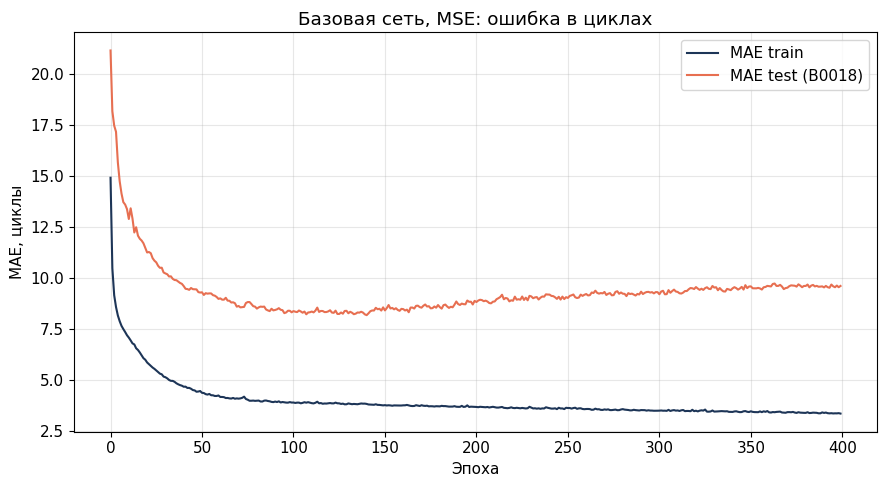

In [13]:
# === Базовая сеть: учим на B0005+B0006, смотрим B0018 ===
base_net = build_regressor(n_in=X_train.shape[1], h1=16, h2=None, seed=42, loss_name="mse")  # d→16→1
base_hist = train_network(  # обучение
    base_net, X_train, y_train_s, y_train, X_test, y_test, y_scaler,
    epochs=400, batch_size=32, lr=0.01, momentum=0.0, verbose_every=50, seed=42,
)

plt.figure(figsize=(9, 5))  # холст
plt.plot(base_hist["mae_train"], label="MAE train", color="#1d3557")  # ошибка на обучении
plt.plot(base_hist["mae_test"], label="MAE test (B0018)", color="#e76f51")  # ошибка на новой батарее
plt.xlabel("Эпоха")  # ось X
plt.ylabel("MAE, циклы")  # ось Y
plt.title("Базовая сеть, MSE: ошибка в циклах")  # заголовок
plt.legend()  # легенда
plt.grid(True, alpha=0.3)  # сетка
plt.tight_layout()  # компоновка
plt.savefig(FIG_DIR / "learning_curves.png", dpi=120, bbox_inches="tight")  # сохранить
plt.show()  # показать


## 7. Метрики на тесте и линейная база

Рядом с сетью — линейная регрессия по тем же стандартизованным признакам (метод наименьших квадратов, та же MSE). Если сеть почти не лучше прямых, зависимость RUL от этих столбцов в основном линейная, и выигрыш сети надо искать в остатке, а не в таблице «мы победили линейную модель».


In [14]:
# === Прогноз базовой сети и линейной регрессии, метрики в циклах ===
y_pred_test = predict_cycles(base_net, X_test, y_scaler)  # сеть на B0018
y_pred_train = predict_cycles(base_net, X_train, y_scaler)  # сеть на train, чтобы видеть переобучение

mae_tr, rmse_tr, r2_tr = regression_scores(y_train, y_pred_train)  # метрики обучения
mae_te, rmse_te, r2_te = regression_scores(y_test, y_pred_test)  # метрики теста

# Линейная модель: y_s = X @ w + b, MSE. Столбец единиц добавляет смещение.
X_train_lin = np.column_stack([np.ones(len(X_train)), X_train])  # (N, 1+d)
X_test_lin = np.column_stack([np.ones(len(X_test)), X_test])  # та же схема для теста
coef, *_ = np.linalg.lstsq(X_train_lin, y_train_s, rcond=None)  # МНК в стандартизованном y
lin_test = y_scaler.inverse_transform(X_test_lin @ coef)  # перевод обратно в циклы
lin_train = y_scaler.inverse_transform(X_train_lin @ coef)  # прогноз линейной модели на train
lin_mae_tr, lin_rmse_tr, lin_r2_tr = regression_scores(y_train, lin_train)  # метрики линейной модели, train
lin_mae_te, lin_rmse_te, lin_r2_te = regression_scores(y_test, lin_test)  # метрики линейной модели, test

print(f"{'Модель':22s} | {'MAE train':>9s} | {'RMSE train':>10s} | {'MAE test':>9s} | {'RMSE test':>10s} | {'R2 test':>8s}")
print("-" * 84)
print(f"{'Dense MSE, 16 нейронов':22s} | {mae_tr:9.2f} | {rmse_tr:10.2f} | {mae_te:9.2f} | {rmse_te:10.2f} | {r2_te:8.3f}")
print(f"{'Линейная регрессия':22s} | {lin_mae_tr:9.2f} | {lin_rmse_tr:10.2f} | {lin_mae_te:9.2f} | {lin_rmse_te:10.2f} | {lin_r2_te:8.3f}")
print()
print(f"Наивный прогноз «всегда среднее RUL train» на тесте:")
naive = np.full_like(y_test, fill_value=float(y_train.mean()))  # константа, без признаков
naive_mae, naive_rmse, _ = regression_scores(y_test, naive)  # ошибка константы
print(f"  MAE {naive_mae:.2f} | RMSE {naive_rmse:.2f} циклов")  # с чем сравнивать сеть


Модель                 | MAE train | RMSE train |  MAE test |  RMSE test |  R2 test
------------------------------------------------------------------------------------
Dense MSE, 16 нейронов |      3.38 |       4.32 |      9.62 |      10.72 |    0.853
Линейная регрессия     |      3.65 |       5.16 |      9.90 |      11.47 |    0.832

Наивный прогноз «всегда среднее RUL train» на тесте:
  MAE 25.34 | RMSE 29.83 циклов


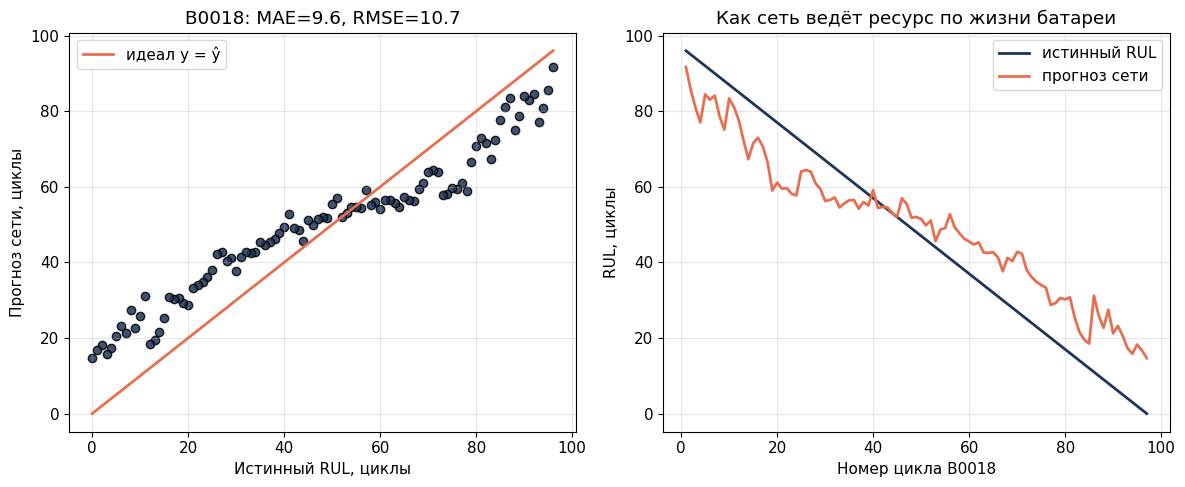

Остаток на B0018: среднее 1.91 циклов, std 10.55
Среднее остатка положительное: сеть в среднем завышает оставшийся ресурс.


In [15]:
# === Прогноз против истины и траектория RUL батареи B0018 ===
y_true = y_test.ravel()  # истина, циклы
y_hat = y_pred_test.ravel()  # прогноз сети, циклы

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # два графика рядом

lo = min(y_true.min(), y_hat.min())  # нижняя граница диагонали
hi = max(y_true.max(), y_hat.max())  # верхняя граница диагонали
axes[0].scatter(y_true, y_hat, c="#1d3557", edgecolors="k", s=36, alpha=0.85)  # каждая точка — цикл B0018
axes[0].plot([lo, hi], [lo, hi], color="#e76f51", lw=2, label="идеал y = ŷ")  # линия идеального прогноза
axes[0].set_xlabel("Истинный RUL, циклы")  # ось X
axes[0].set_ylabel("Прогноз сети, циклы")  # ось Y
axes[0].set_title(f"B0018: MAE={mae_te:.1f}, RMSE={rmse_te:.1f}")  # заголовок с метриками
axes[0].legend()  # легенда
axes[0].grid(True, alpha=0.3)  # сетка

order = np.argsort(test_df["cycle_index"].to_numpy())  # циклы B0018 по времени, не в случайном порядке
axes[1].plot(test_df["cycle_index"].to_numpy()[order], y_true[order], label="истинный RUL", color="#1d3557", lw=2)
axes[1].plot(test_df["cycle_index"].to_numpy()[order], y_hat[order], label="прогноз сети", color="#e76f51", lw=2)
axes[1].set_xlabel("Номер цикла B0018")  # ось X
axes[1].set_ylabel("RUL, циклы")  # ось Y
axes[1].set_title("Как сеть ведёт ресурс по жизни батареи")  # заголовок
axes[1].legend()  # легенда
axes[1].grid(True, alpha=0.3)  # сетка

plt.tight_layout()  # компоновка
plt.savefig(FIG_DIR / "pred_vs_true.png", dpi=120, bbox_inches="tight")  # сохранить оба графика
plt.show()  # показать

resid = y_hat - y_true  # остаток: прогноз минус истина
print(f"Остаток на B0018: среднее {resid.mean():.2f} циклов, std {resid.std():.2f}")  # смещение и разброс
if resid.mean() < 0:  # прогноз меньше истины
    print("Среднее остатка отрицательное: сеть в среднем занижает оставшийся ресурс.")
else:  # прогноз больше истины
    print("Среднее остатка положительное: сеть в среднем завышает оставшийся ресурс.")


## 8. Эксперименты

Меняем **один** фактор, остальное держим как в базе (кроме числа эпох: в сетке 250, чтобы сравнение было одинаковым). Смотрим MAE на B0018 — в циклах.


In [16]:
# === Обёртка эксперимента: собрать сеть, обучить, вернуть итоговые метрики ===

def run_experiment(
    name, feature_cols=None, h1=16, h2=None, lr=0.01, momentum=0.0,
    loss_name="mse", epochs=250, seed=42,
):
    '''Один прогон. feature_cols=None — полный набор признаков.'''
    feature_cols = feature_cols or FEATURE_COLS  # какие столбцы подавать
    Xtr_raw, ytr = make_xy(train_df, feature_cols)  # train под этот набор признаков
    Xte_raw, yte = make_xy(test_df, feature_cols)  # test под тот же набор
    sx = StandardScaler().fit(Xtr_raw)  # масштаб признаков только по train
    sy = StandardScaler().fit(ytr)  # масштаб RUL только по train
    Xtr = sx.transform(Xtr_raw)  # стандартизованный train
    Xte = sx.transform(Xte_raw)  # стандартизованный test
    net = build_regressor(Xtr.shape[1], h1=h1, h2=h2, seed=seed, loss_name=loss_name)  # новая сеть с нуля
    hist = train_network(  # учим без печати каждой эпохи
        net, Xtr, sy.transform(ytr), ytr, Xte, yte, sy,
        epochs=epochs, batch_size=32, lr=lr, momentum=momentum,
        verbose_every=0, seed=seed,
    )
    result = {  # компактный итог для таблицы
        "name": name,
        "mae_train": hist["mae_train"][-1],
        "rmse_train": hist["rmse_train"][-1],
        "mae_test": hist["mae_test"][-1],
        "rmse_test": hist["rmse_test"][-1],
        "hist": hist,
    }
    print(
        f"{name:28s} | MAE train {result['mae_train']:6.2f} | "
        f"MAE test {result['mae_test']:6.2f} | RMSE test {result['rmse_test']:6.2f}"
    )
    return result  # словарь с кривыми и числами


def plot_test_mae(results, title, filename):
    '''Несколько кривых MAE на B0018.'''
    plt.figure(figsize=(9, 5))  # холст
    for result in results:  # одна кривая — один прогон
        plt.plot(result["hist"]["mae_test"], label=result["name"])  # ошибка на тесте
    plt.xlabel("Эпоха")  # ось X
    plt.ylabel("MAE test, циклы")  # ось Y
    plt.title(title)  # заголовок
    plt.legend(fontsize=8)  # легенда
    plt.grid(True, alpha=0.3)  # сетка
    plt.tight_layout()  # компоновка
    plt.savefig(FIG_DIR / filename, dpi=120, bbox_inches="tight")  # сохранить
    plt.show()  # показать


lr=0.001                     | MAE train   5.54 | MAE test  10.86 | RMSE test  12.86


lr=0.01                      | MAE train   3.66 | MAE test   9.08 | RMSE test  10.06


lr=0.1                       | MAE train   3.03 | MAE test   7.24 | RMSE test   8.56


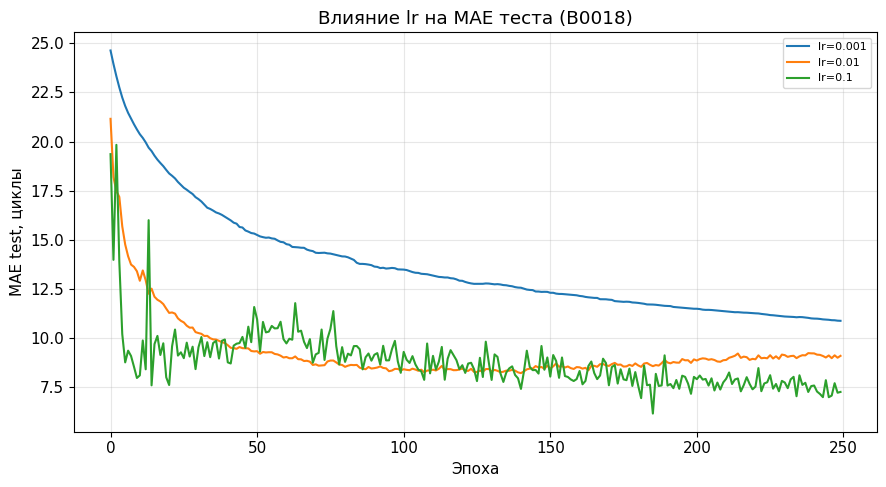

In [17]:
# === 8.1 Скорость обучения ===
lr_results = []  # список прогонов
for lr in (0.001, 0.01, 0.1):  # маленький, базовый, слишком большой
    lr_results.append(run_experiment(f"lr={lr}", lr=lr, epochs=250))  # меняется только lr
plot_test_mae(lr_results, "Влияние lr на MAE теста (B0018)", "exp_lr.png")  # график


hidden=4                     | MAE train   3.73 | MAE test   3.51 | RMSE test   4.58


hidden=16                    | MAE train   3.66 | MAE test   9.08 | RMSE test  10.06


hidden=32                    | MAE train   3.44 | MAE test   4.54 | RMSE test   5.89


hidden=16/8                  | MAE train   3.49 | MAE test  19.47 | RMSE test  23.65


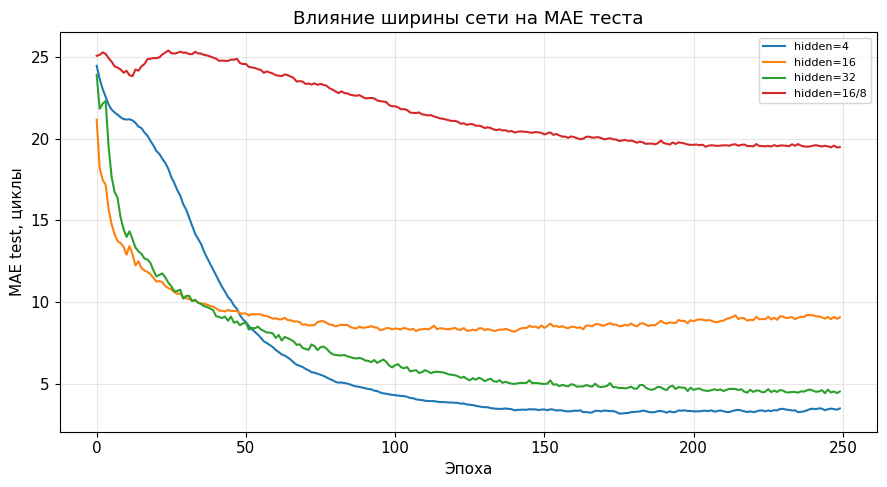

In [18]:
# === 8.2 Ширина скрытых слоёв ===
width_results = []  # список прогонов
for h1, h2, title in ((4, None, "hidden=4"), (16, None, "hidden=16"), (32, None, "hidden=32"), (16, 8, "hidden=16/8")):
    width_results.append(run_experiment(title, h1=h1, h2=h2, lr=0.01, epochs=250))  # ширина и глубина
plot_test_mae(width_results, "Влияние ширины сети на MAE теста", "exp_width.png")  # график


loss=MSE                     | MAE train   3.66 | MAE test   9.08 | RMSE test  10.06


loss=MAE                     | MAE train   3.23 | MAE test   9.18 | RMSE test  10.17


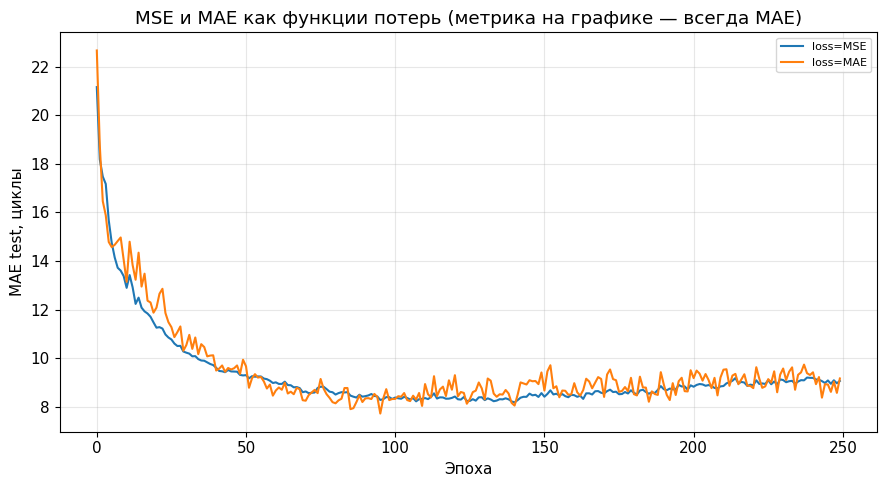

In [19]:
# === 8.3 Функция потерь: MSE против MAE ===
loss_results = [
    run_experiment("loss=MSE", loss_name="mse", lr=0.01, epochs=250),  # квадрат ошибки
    run_experiment("loss=MAE", loss_name="mae", lr=0.01, epochs=250),  # модуль ошибки
]
plot_test_mae(loss_results, "MSE и MAE как функции потерь (метрика на графике — всегда MAE)", "exp_loss.png")


ёмкость + датчики            | MAE train   3.66 | MAE test   9.08 | RMSE test  10.06


без ёмкости и времени        | MAE train   4.84 | MAE test  27.63 | RMSE test  34.22


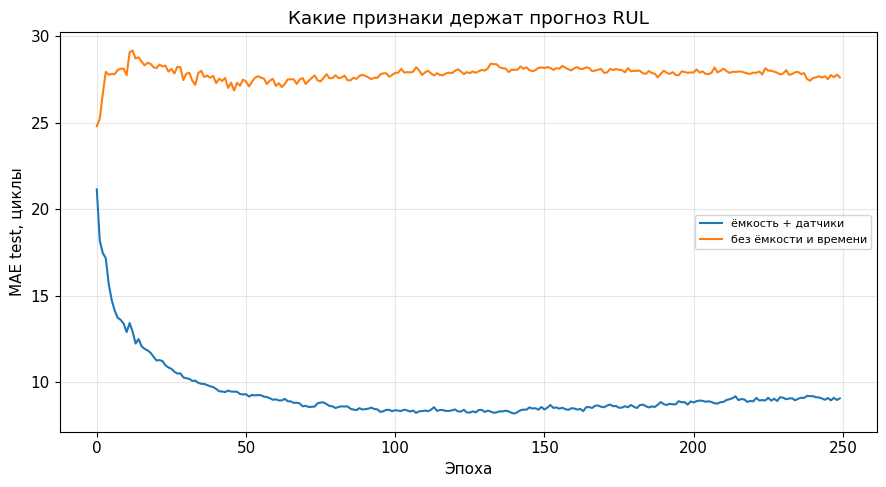

In [20]:
# === 8.4 Набор признаков: с ёмкостью и без прямых индикаторов здоровья ===
sensor_only = ["v_mean", "v_min", "v_std", "v_end", "t_mean", "t_max", "t_rise"]  # только напряжение и температура
feature_results = [
    run_experiment("ёмкость + датчики", feature_cols=FEATURE_COLS, lr=0.01, epochs=250),  # полный набор
    run_experiment("без ёмкости и времени", feature_cols=sensor_only, lr=0.01, epochs=250),  # без прокси ресурса
]
plot_test_mae(feature_results, "Какие признаки держат прогноз RUL", "exp_features.png")  # график


In [21]:
# === Сводная таблица ===
all_results = lr_results + width_results + loss_results + feature_results  # все прогоны сетки
print(f"{'Эксперимент':28s} | {'MAE train':>9s} | {'RMSE train':>10s} | {'MAE test':>9s} | {'RMSE test':>10s}")
print("-" * 80)
for result in all_results:  # строка на прогон
    print(
        f"{result['name']:28s} | {result['mae_train']:9.2f} | {result['rmse_train']:10.2f} | "
        f"{result['mae_test']:9.2f} | {result['rmse_test']:10.2f}"
    )

finite = [r for r in all_results if np.isfinite(r["mae_test"])]  # прогоны, которые не развалились
best = min(finite, key=lambda r: r["mae_test"])  # лучший по MAE на B0018
print()
print(f"Лучший в сетке по MAE test: {best['name']} = {best['mae_test']:.2f} циклов")
print(f"База (400 эпох) MAE test = {mae_te:.2f}, RMSE test = {rmse_te:.2f}")
print(f"Линейная регрессия MAE test = {lin_mae_te:.2f}, RMSE test = {lin_rmse_te:.2f}")


Эксперимент                  | MAE train | RMSE train |  MAE test |  RMSE test
--------------------------------------------------------------------------------
lr=0.001                     |      5.54 |       7.85 |     10.86 |      12.86
lr=0.01                      |      3.66 |       4.59 |      9.08 |      10.06
lr=0.1                       |      3.03 |       4.09 |      7.24 |       8.56
hidden=4                     |      3.73 |       4.82 |      3.51 |       4.58
hidden=16                    |      3.66 |       4.59 |      9.08 |      10.06
hidden=32                    |      3.44 |       4.58 |      4.54 |       5.89
hidden=16/8                  |      3.49 |       4.56 |     19.47 |      23.65
loss=MSE                     |      3.66 |       4.59 |      9.08 |      10.06
loss=MAE                     |      3.23 |       4.36 |      9.18 |      10.17
ёмкость + датчики            |      3.66 |       4.59 |      9.08 |      10.06
без ёмкости и времени        |      4.84 |       6

### Что видно по сетке

- **Малый lr (0.001)** за 250 эпох не доходит до ошибки шага 0.01: градиент верный, шаги короткие (MAE теста около 11 циклов против 9 у `lr=0.01`).
- **Крупный lr (0.1)** здесь не развалился: норма градиента обрезается на 5, и на B0018 MAE даже ниже (около 7 циклов). Без обрезки тот же шаг легко уводит веса в `inf`. Один удачный прогон не значит, что lr надо всегда увеличивать.
- **Один скрытый слой** близок к линейной регрессии: RUL почти линейно сидит на ёмкости. Узкая сеть (`hidden=4`) на этом зерне дала меньшую ошибку теста, чем 16 нейронов. **Второй скрытый слой 16/8** при той же ошибке на train (около 3.5 цикла) на B0018 ошибается примерно на 19 циклов — глубина запомнила обучающие батареи.
- **MAE-loss** оптимизирует как раз ту величину, которой мы отчитываемся. На RMSE она не обязана выиграть: RMSE смотрит на крупные промахи, а MAE-loss их не штрафует квадратом.
- **Без ёмкости и длительности разряда** ошибка заметно выше. При токе около 2 А время разряда — почти та же ёмкость. Напряжение и температура старение чувствуют, но слабее.


## 9. Ответы на контрольные вопросы

1. **Почему на выходе linear, а не Softmax?**  
   RUL — число циклов, шкала не ограничена отрезком \((0,1)\) и это не распределение по классам. Softmax даёт вероятности, которые в сумме равны 1. Линейный выход может быть любым вещественным числом; отрицательный прогноз тогда виден как ошибка модели, а не спрятан насыщением.

2. **Чем функция потерь MSE отличается от метрики RMSE?**  
   MSE — то, чей градиент идёт в backprop: средний квадрат, в квадратах циклов (ещё и в масштабе стандартизованного \(y\)). RMSE — корень из MSE уже в циклах, им сравнивают модели. Минимизировать MSE и RMSE — одна и та же задача (корень монотонен), но в отчёте читают RMSE, потому что единица совпадает с целью.

3. **Почему MAE-loss устойчивее к выбросам, чем MSE?**  
   Вклад объекта в MSE растёт как квадрат ошибки, в MAE — линейно. Цикл с аномальной регенерацией ёмкости сдвигает веса MSE гораздо сильнее. Плата — в нуле нет обычной производной, и крупные, но редкие промахи модель почти не «боится».

4. **Зачем стандартизовать и \(X\), и \(y\)? Почему метрики — после обратного преобразования?**  
   Признаки в разных единицах (секунды, вольты, градусы, А·ч). Без общей шкалы шаг `lr` по одним весам огромный, по другим — пустой. Стандартизованный \(y\) держит стартовый loss порядка 1, и тот же `lr` осмысленен. MAE «0.3» в этих единицах не переводится в циклы, пока не применить `inverse_transform` с μ и σ **обучающей** выборки.

5. **Почему нельзя случайно делить циклы одной батареи?**  
   Соседние циклы почти повторяют друг друга. Цикл 50 в тесте угадывается по циклу 49 в обучении, метрика завышена и не отвечает на вопрос «сработает ли модель на новой ячейке». Здесь тест — целиком B0018.

6. **Почему ёмкость так сильно связана с RUL? Что было бы утечкой?**  
   Порог EOL задан по ёмкости, а деградация в среднем монотонная, поэтому текущая ёмкость уже почти говорит, сколько осталось. Длительность разряда при фиксированном токе — тот же сигнал. Утечка — положить в признаки сам `rul`, номер цикла до известного EOL или любую статистику, посчитанную по будущим циклам (например, скорость падения с заполнением вперёд).

7. **Почему RMSE не бывает меньше MAE на одних и тех же ошибках?**  
   RMSE — квадратичное среднее модулей ошибок, MAE — арифметическое. Квадратичное среднее не меньше арифметического. Они совпадают, только когда все абсолютные ошибки равны.

8. **Что делать с отрицательным прогнозом RUL?**  
   Оставшийся ресурс не бывает отрицательным. Linear-выход это не знает. Для отчёта можно взять \(\max(0, \hat y)\), но метрики выше посчитаны без обрезки, чтобы было видно сырое поведение сети.


## 10. Выводы

1. Задача поставлена как регрессия: Dense-сеть \(d \rightarrow 16 \rightarrow 1\), на выходе linear, обучающий сигнал — градиент MSE. Численная проверка градиента сходится с аналитической (ошибка \(< 10^{-6}\)).
2. Метрики считаются в циклах на батарее B0018, которой не было в обучении. Константа «среднее RUL train» и линейная регрессия по тем же столбцам — ориентир. Если сеть почти не лучше прямой, зависимость в этих столбцах в основном линейная.
3. Сильнее всего RUL держат ёмкость и длительность разряда (корреляция на train 0.94 и 0.96). Без них MAE на B0018 около 28 циклов — не лучше наивного «всегда среднее», то есть напряжение и температура сами по себе на новую ячейку не переносятся.
4. Шаг 0.001 за 250 эпох не доучивается. Шаг 0.1 при обрезке градиента на этом прогоне устойчив и даёт меньшую ошибку теста; без обрезки такой шаг опасен. Второй скрытый слой 16/8 запоминает B0005 и B0006 (MAE train около 3.5) и плохо переносится на B0018 (MAE около 19). MSE и MAE как функции потерь на этой таблице почти совпали по метрикам.
5. B0007 на графике деградации есть, в выборке регрессии её нет: другой порог напряжения разряда, ёмкость нельзя ставить в один ряд с B0005/B0006/B0018.
